# Partie III — Analyse de Rapports Médicaux avec RNN / LSTM / GRU
## Classification et Résumé Automatique — MTSamples Medical Transcriptions
### EMSI — Deep Learning — 2025/2026

---

## Plan du Notebook

1. **Théorie** : Modèles de langage, Tokenisation, Embeddings, BPTT, Vanishing Gradient, Teacher Forcing, Seq2Seq, Beam Search, BLEU
2. **Prétraitement** : Nettoyage, tokenisation, padding, vocabulaire
3. **Modèles** : `nn.RNN`, `nn.LSTM`, `nn.GRU`
4. **Étude Comparative** : Accuracy, temps, mémoire, stabilité
5. **Gradient Clipping** : Sans, clip=1, clip=5
6. **Mini Projet Seq2Seq** : Résumé automatique avec Greedy et Beam Search
7. **Évaluation** : Accuracy, BLEU Score, Perplexité
8. **Synthèse**

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

import re, time, os, math, warnings
from typing import List, Dict, Tuple, Optional

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs('../data/mtsamples', exist_ok=True)

print(f'Device : {device}')
print('Configuration RNN/LSTM/GRU terminee')

Device : cpu
Configuration RNN/LSTM/GRU terminee


---
## 1. Théorie — Modèles Séquentiels

### 1.1 Modèle de Langage

Un modèle de langage estime la probabilité d'une séquence :

$$P(w_1, w_2, ..., w_T) = \prod_{t=1}^{T} P(w_t | w_1, ..., w_{t-1})$$

**Factorisation probabiliste** :
$$\log P(w_{1:T}) = \sum_{t=1}^{T} \log P(w_t | w_{<t})$$

### 1.2 RNN — Équations Fondamentales

$$\mathbf{h}_t = \tanh(\mathbf{W}_{xh} \mathbf{x}_t + \mathbf{W}_{hh} \mathbf{h}_{t-1} + \mathbf{b}_h)$$
$$\mathbf{y}_t = \mathbf{W}_{hy} \mathbf{h}_t + \mathbf{b}_y$$

**Problème** : Le gradient disparaît sur les longues séquences (Vanishing Gradient) :
$$\frac{\partial \mathcal{L}}{\partial \mathbf{h}_0} = \prod_{t=1}^{T} \frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-1}} \approx 0 \text{ si } T \text{ grand}$$

### 1.3 LSTM — Long Short-Term Memory

Le LSTM utilise des portes pour contrôler le flux d'information :

| Porte | Formule | Rôle |
|-------|---------|------|
| **Oubli (f)** | $\sigma(W_f[h_{t-1}, x_t] + b_f)$ | Ce qu'on oublie de la cellule |
| **Entrée (i)** | $\sigma(W_i[h_{t-1}, x_t] + b_i)$ | Ce qu'on ajoute à la cellule |
| **Sortie (o)** | $\sigma(W_o[h_{t-1}, x_t] + b_o)$ | Ce qu'on expose comme état caché |
| **Cellule (c)** | $f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ | Mémoire à long terme |

### 1.4 GRU — Gated Recurrent Unit

Version simplifiée du LSTM avec 2 portes au lieu de 3 :

$$\mathbf{z}_t = \sigma(\mathbf{W}_z [\mathbf{h}_{t-1}, \mathbf{x}_t])  \quad \text{(Porte de mise a jour)}$$
$$\mathbf{r}_t = \sigma(\mathbf{W}_r [\mathbf{h}_{t-1}, \mathbf{x}_t])  \quad \text{(Porte de reinitialisation)}$$
$$\mathbf{h}_t = (1-\mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t$$

### 1.5 Perplexité

$$\text{PPL} = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(w_i)\right) = \exp(\mathcal{H})$$

Plus la perplexité est basse, meilleur est le modèle de langage.

---
## 2. Prétraitement du Dataset

In [2]:
def load_mtsamples(filepath='../data/mtsamples/mtsamples.csv', n_classes=5):
    """Charge le dataset MTSamples depuis le CSV."""
    df = pd.read_csv(filepath)
    # Nettoyage basique
    df = df.dropna(subset=['transcription', 'medical_specialty'])
    # Garder les top N classes
    top_classes = df['medical_specialty'].value_counts().nlargest(n_classes).index.tolist()
    df = df[df['medical_specialty'].isin(top_classes)].copy()
    
    # Mapping des labels
    specialties = {i: name.strip() for i, name in enumerate(top_classes)}
    name2id = {name.strip(): i for i, name in enumerate(top_classes)}
    
    df['label'] = df['medical_specialty'].apply(lambda x: name2id[x.strip()])
    df['text'] = df['transcription']
    df['specialty'] = df['medical_specialty'].str.strip()
    
    return df[['text', 'label', 'specialty']].reset_index(drop=True), specialties

df, SPECIALTIES = load_mtsamples()
print('='*55)
print('  DATASET : MTSamples (Reel)')
print('='*55)
print(f'  Taille totale : {len(df)}')
print(f'  Classes       : {len(SPECIALTIES)}')
for cls, name in SPECIALTIES.items():
    n = (df['label'] == cls).sum()
    print(f'    {name:30s} : {n}')
df.head()

  DATASET : MTSamples (Reel)
  Taille totale : 2603
  Classes       : 5
    Surgery                        : 1088
    Consult - History and Phy.     : 516
    Cardiovascular / Pulmonary     : 371
    Orthopedic                     : 355
    Radiology                      : 273


,text,label,specialty
0,"2-D M-MODE: , ,1. Left atrial enlargement wit...",2,Cardiovascular / Pulmonary
1,1. The left ventricular cavity size and wall ...,2,Cardiovascular / Pulmonary
2,"2-D ECHOCARDIOGRAM,Multiple views of the heart...",2,Cardiovascular / Pulmonary
3,"DESCRIPTION:,1. Normal cardiac chambers size....",2,Cardiovascular / Pulmonary
4,"2-D STUDY,1. Mild aortic stenosis, widely calc...",2,Cardiovascular / Pulmonary


In [3]:
class Vocabulary:
    """Gere le vocabulaire : token vers index et index vers token."""

    PAD_TOKEN = '<PAD>'
    UNK_TOKEN = '<UNK>'
    SOS_TOKEN = '<SOS>'
    EOS_TOKEN = '<EOS>'

    def __init__(self, min_freq=1):
        self.min_freq  = min_freq
        self.token2idx = {}
        self.idx2token = {}
        self._special  = [self.PAD_TOKEN, self.UNK_TOKEN,
                           self.SOS_TOKEN, self.EOS_TOKEN]

    def build(self, texts: List[str]):
        """Construit le vocabulaire a partir d'une liste de textes."""
        counter = Counter()
        for text in texts:
            counter.update(self._tokenize(text))

        self.token2idx = {t: i for i, t in enumerate(self._special)}
        for token, freq in counter.most_common():
            if freq >= self.min_freq and token not in self.token2idx:
                self.token2idx[token] = len(self.token2idx)

        self.idx2token = {v: k for k, v in self.token2idx.items()}
        return self

    def _tokenize(self, text: str) -> List[str]:
        """Tokenisation simple : minuscules et split."""
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
        return text.split()

    def encode(self, text: str, max_len: int = 50) -> List[int]:
        """Convertit un texte en liste d'indices avec padding et truncation."""
        tokens = self._tokenize(text)[:max_len]
        ids    = [self.token2idx.get(t, self.token2idx[self.UNK_TOKEN]) for t in tokens]
        ids   += [self.token2idx[self.PAD_TOKEN]] * (max_len - len(ids))
        return ids

    def decode(self, ids: List[int]) -> str:
        """Convertit une liste d'indices en texte."""
        return ' '.join([
            self.idx2token.get(i, self.UNK_TOKEN)
            for i in ids
            if i != self.token2idx[self.PAD_TOKEN]
        ])

    def __len__(self): return len(self.token2idx)


MAX_LEN   = 50
EMBED_DIM = 64

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(),
    test_size=0.3, random_state=SEED, stratify=df['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

vocab = Vocabulary(min_freq=1).build(train_texts)

print(f'  Taille du vocabulaire : {len(vocab)}')
print(f'  Max longueur sequence : {MAX_LEN}')
print(f'  Train : {len(train_texts)} | Val : {len(val_texts)} | Test : {len(test_texts)}')

sample_text = train_texts[0]
encoded = vocab.encode(sample_text, MAX_LEN)
decoded = vocab.decode(encoded)
print(f'\nExemple :')
print(f'  Texte   : {sample_text[:60]}...')
print(f'  Encode  : {encoded[:10]}...')
print(f'  Decode  : {decoded[:60]}...')

  Taille du vocabulaire : 20614
  Max longueur sequence : 50
  Train : 1822 | Val : 390 | Test : 391

Exemple :
  Texte   : PREPROCEDURE DIAGNOSIS:,  Left leg claudication.,POSTPROCEDU...
  Encode  : [4673, 75, 23, 427, 4492, 2910, 75, 23, 427, 4492]...
  Decode  : preprocedure diagnosis left leg claudication postprocedure d...


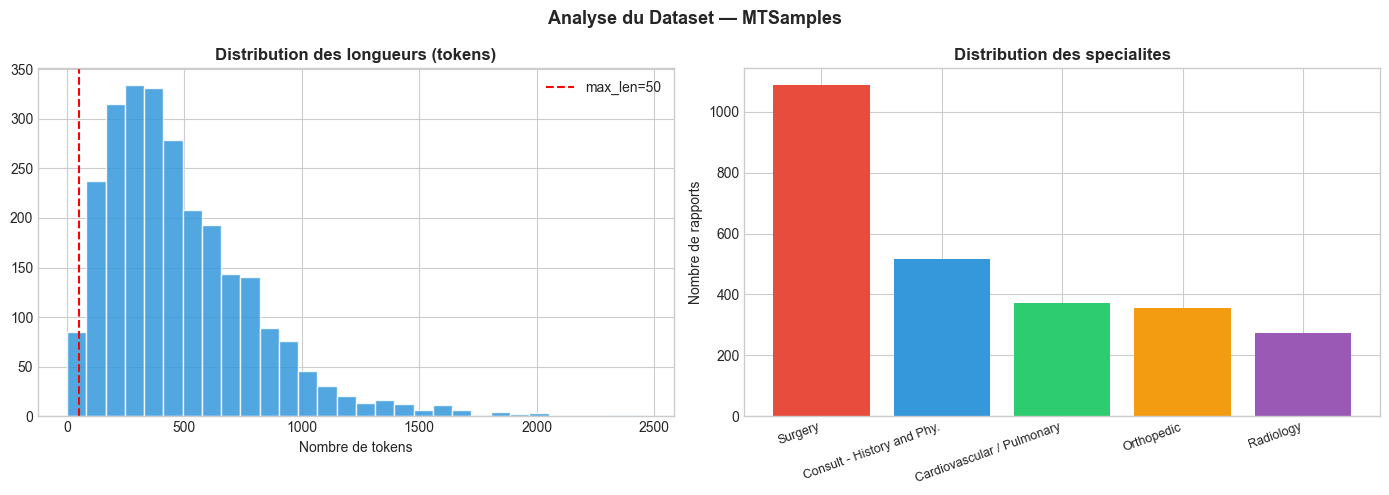

In [4]:
class MedicalTextDataset(Dataset):
    """Dataset de textes medicaux pour classification."""

    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts  = [torch.tensor(vocab.encode(t, max_len), dtype=torch.long) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.texts[i], self.labels[i]


train_ds   = MedicalTextDataset(train_texts, train_labels, vocab, MAX_LEN)
val_ds     = MedicalTextDataset(val_texts,   val_labels,   vocab, MAX_LEN)
test_ds    = MedicalTextDataset(test_texts,  test_labels,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

lengths = [len(t.split()) for t in df['text']]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse du Dataset — MTSamples', fontsize=13, fontweight='bold')

axes[0].hist(lengths, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(MAX_LEN, color='red', linestyle='--', label=f'max_len={MAX_LEN}')
axes[0].set_title('Distribution des longueurs (tokens)', fontweight='bold')
axes[0].set_xlabel('Nombre de tokens'); axes[0].legend()

counts = df['specialty'].value_counts()
axes[1].bar(range(len(counts)), counts.values,
            color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Distribution des specialites', fontweight='bold')
axes[1].set_ylabel('Nombre de rapports')

plt.tight_layout()
plt.show()

---
## 3. Implémentations — RNN, LSTM, GRU

In [5]:
class MedicalTextClassifier(nn.Module):
    """
    Classifieur de textes medicaux avec RNN / LSTM / GRU.

    Architecture :
        Embedding -> RNN/LSTM/GRU -> Pooling -> Dense -> Softmax

    Args:
        vocab_size   : Taille du vocabulaire
        embed_dim    : Dimension des embeddings
        hidden_dim   : Dimension de l'etat cache
        n_classes    : Nombre de classes
        rnn_type     : 'rnn', 'lstm', 'gru'
        n_layers     : Nombre de couches recurrentes
        dropout      : Taux de dropout
        bidirectional: Si True, RNN bidirectionnel
    """

    def __init__(
        self,
        vocab_size    : int,
        embed_dim     : int   = 64,
        hidden_dim    : int   = 128,
        n_classes     : int   = 5,
        rnn_type      : str   = 'lstm',
        n_layers      : int   = 2,
        dropout       : float = 0.3,
        bidirectional : bool  = False,
    ):
        super().__init__()

        assert rnn_type in ('rnn', 'lstm', 'gru'), \
            f"rnn_type doit etre 'rnn', 'lstm' ou 'gru'"

        self.rnn_type      = rnn_type
        self.bidirectional = bidirectional
        directions         = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = n_layers,
            batch_first   = True,
            dropout       = dropout if n_layers > 1 else 0,
            bidirectional = bidirectional,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * directions, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        """
        Args:
            x : Tenseur de tokens (batch_size, seq_len)
        Returns:
            Logits (batch_size, n_classes)
        """
        embedded = self.embedding(x)

        if self.rnn_type == 'lstm':
            output, (hn, cn) = self.rnn(embedded)
        else:
            output, hn = self.rnn(embedded)

        if self.bidirectional:
            h = torch.cat([hn[-2], hn[-1]], dim=1)
        else:
            h = hn[-1]

        return self.classifier(h)


N_CLASSES  = len(SPECIALTIES)
VOCAB_SIZE = len(vocab)

for rnn_type in ['rnn', 'lstm', 'gru']:
    m = MedicalTextClassifier(VOCAB_SIZE, rnn_type=rnn_type)
    x = torch.randint(0, VOCAB_SIZE, (4, MAX_LEN))
    out = m(x)
    params = sum(p.numel() for p in m.parameters())
    print(f'[{rnn_type.upper():4s}] Input: {x.shape} -> Output: {out.shape} | Params: {params:,}')

[RNN ] Input: torch.Size([4, 50]) -> Output: torch.Size([4, 5]) | Params: 1,385,733
[LSTM] Input: torch.Size([4, 50]) -> Output: torch.Size([4, 5]) | Params: 1,559,301
[GRU ] Input: torch.Size([4, 50]) -> Output: torch.Size([4, 5]) | Params: 1,501,445


In [6]:
def train_rnn(model, train_loader, val_loader,
              n_epochs=2, lr=1e-3, clip=None,
              patience=12, verbose=True, label='RNN'):
    """
    Entraine un modele RNN/LSTM/GRU.

    Args:
        clip : Seuil de gradient clipping (None = pas de clipping)
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'grad_norms':[]}
    best_val = float('inf'); best_state = None; pat = 0; t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        model.train()
        tl, ta, n, grad_norms = 0, 0, 0, []

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()

            if clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item()**2
            grad_norms.append(total_norm**0.5)

            optimizer.step()
            tl += loss.item()*Xb.size(0)
            ta += (out.argmax(1) == yb).sum().item()
            n  += Xb.size(0)

        model.eval()
        vl, va, m = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                vl += criterion(out, yb).item()*Xb.size(0)
                va += (out.argmax(1) == yb).sum().item()
                m  += Xb.size(0)

        history['train_loss'].append(tl/n);  history['val_loss'].append(vl/m)
        history['train_acc'].append(ta/n);   history['val_acc'].append(va/m)
        history['grad_norms'].append(np.mean(grad_norms))
        scheduler.step()

        if verbose and epoch % 10 == 0:
            clip_str = f'clip={clip}' if clip else 'no_clip'
            print(f'  [{clip_str}] Ep.{epoch:>3} | '
                  f'Train acc={ta/n:.4f} | Val acc={va/m:.4f} | '
                  f'Grad norm={np.mean(grad_norms):.2f}')

        if vl/m < best_val:
            best_val = vl/m
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat = 0
        else:
            pat += 1
            if pat >= patience: break

    model.load_state_dict(best_state)
    history['time'] = time.time() - t0
    history['best_val_loss'] = best_val
    if verbose:
        print(f'  {label} — {history["time"]:.1f}s')
    return model, history


print('Boucle d\'entrainement prete')

Boucle d'entrainement prete


---
## 4. Étude Comparative — RNN vs LSTM vs GRU

In [7]:
def evaluate_rnn(model, loader):
    model.eval()
    y_true_l, y_pred_l = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            out  = model(Xb.to(device))
            pred = out.argmax(1).cpu().numpy()
            y_pred_l.append(pred)
            y_true_l.append(yb.numpy())
    y_true = np.concatenate(y_true_l)
    y_pred = np.concatenate(y_pred_l)
    return {'accuracy': accuracy_score(y_true, y_pred),
            'y_true': y_true, 'y_pred': y_pred}


rnn_models    = {}
rnn_histories = {}
rnn_metrics   = {}

print('Comparaison RNN / LSTM / GRU')
print('='*55)

for rnn_type in ['rnn', 'lstm', 'gru']:
    print(f'\n  Entrainement {rnn_type.upper()}...')
    m = MedicalTextClassifier(
        VOCAB_SIZE, embed_dim=64, hidden_dim=128,
        n_classes=N_CLASSES, rnn_type=rnn_type, n_layers=2
    )
    m, h = train_rnn(m, train_loader, val_loader,
                     n_epochs=2, verbose=True, label=rnn_type.upper())
    mets = evaluate_rnn(m, test_loader)
    mets['time']   = h['time']
    mets['params'] = sum(p.numel() for p in m.parameters())

    rnn_models[rnn_type]    = m
    rnn_histories[rnn_type] = h
    rnn_metrics[rnn_type]   = mets

print('\n' + '='*55)
print(f'  {"Modele":8s} | {"Accuracy":>10} | {"Params":>10} | {"Temps":>8}')
print('-'*55)
for name, m in rnn_metrics.items():
    print(f'  {name.upper():8s} | {m["accuracy"]:>10.4f} | {m["params"]:>10,} | {m["time"]:>7.1f}s')
print('='*55)

Comparaison RNN / LSTM / GRU

  Entrainement RNN...


  RNN — 2.9s

  Entrainement LSTM...


  LSTM — 4.1s

  Entrainement GRU...


  GRU — 10.6s



  Modele   |   Accuracy |     Params |    Temps
-------------------------------------------------------
  RNN      |     0.5601 |  1,385,733 |     2.9s
  LSTM     |     0.5652 |  1,559,301 |     4.1s
  GRU      |     0.5908 |  1,501,445 |    10.6s


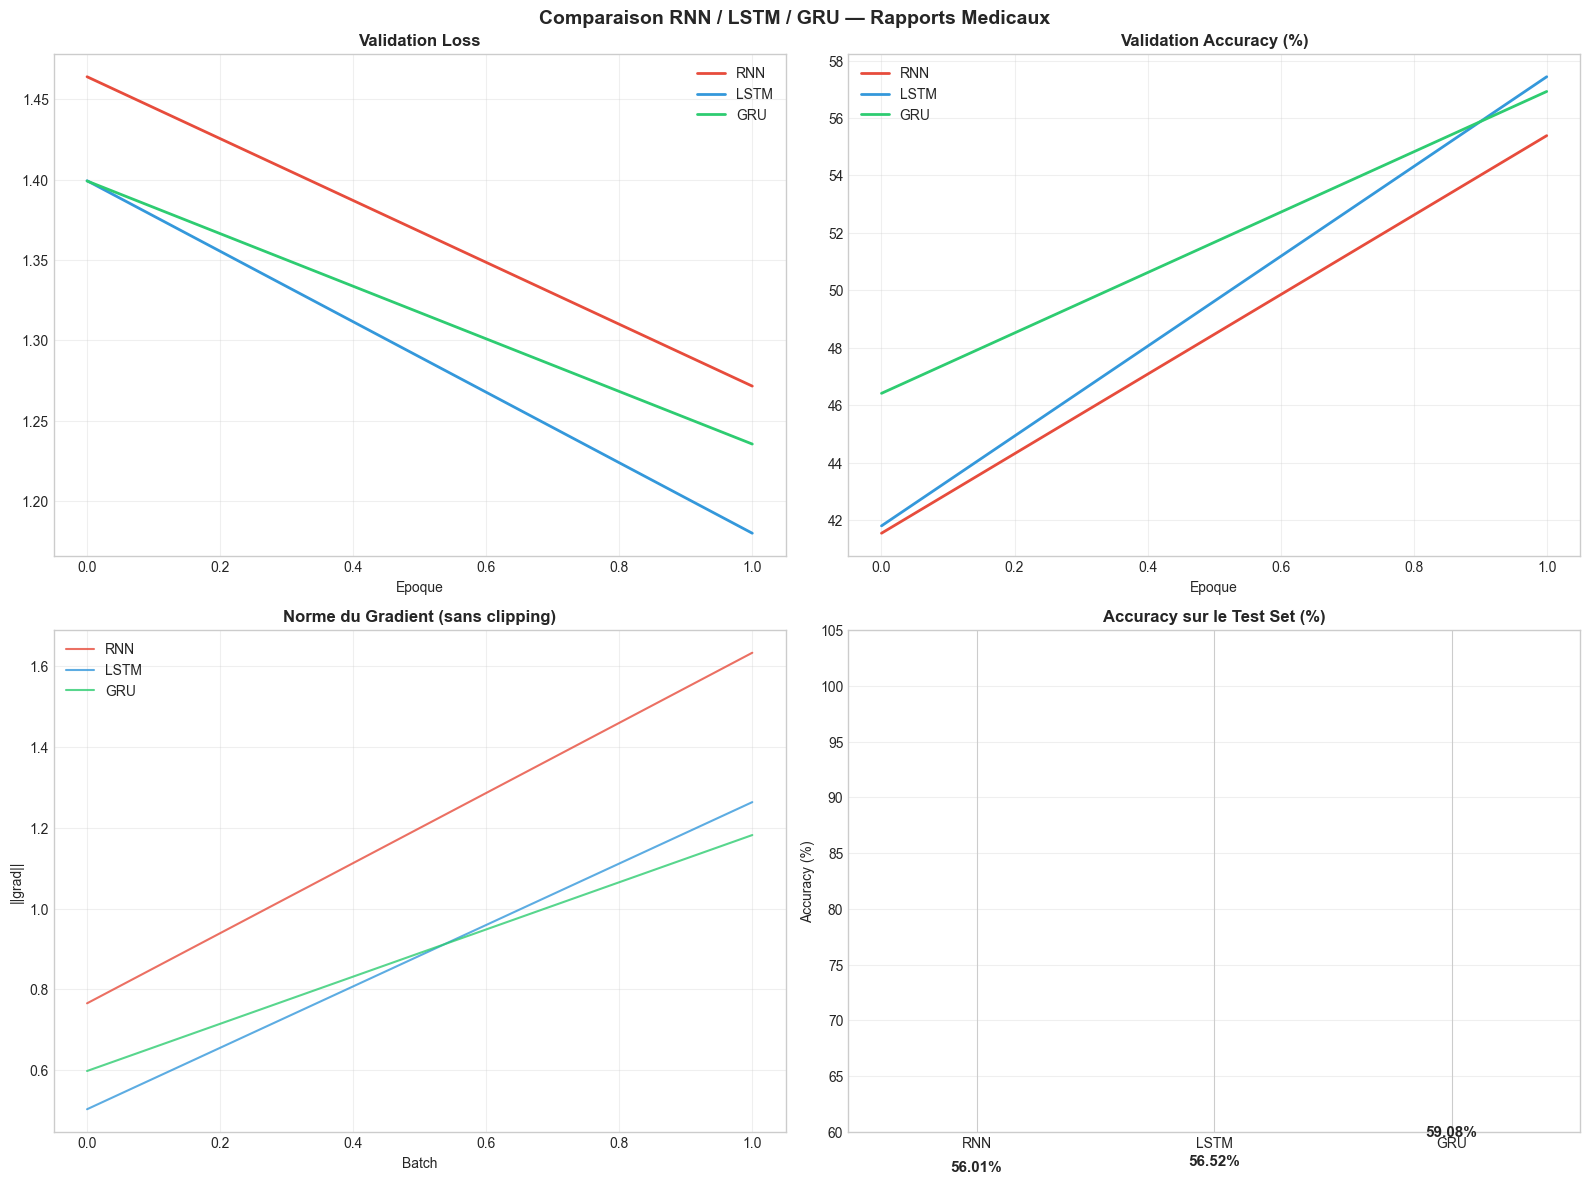

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison RNN / LSTM / GRU — Rapports Medicaux',
             fontsize=14, fontweight='bold')

colors = {'rnn': '#e74c3c', 'lstm': '#3498db', 'gru': '#2ecc71'}

for name, h in rnn_histories.items():
    axes[0,0].plot(h['val_loss'], color=colors[name], lw=2, label=name.upper())
axes[0,0].set_title('Validation Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoque'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

for name, h in rnn_histories.items():
    axes[0,1].plot([a*100 for a in h['val_acc']],
                   color=colors[name], lw=2, label=name.upper())
axes[0,1].set_title('Validation Accuracy (%)', fontweight='bold')
axes[0,1].set_xlabel('Epoque'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

for name, h in rnn_histories.items():
    axes[1,0].plot(h['grad_norms'], color=colors[name], lw=1.5, alpha=0.8, label=name.upper())
axes[1,0].set_title('Norme du Gradient (sans clipping)', fontweight='bold')
axes[1,0].set_xlabel('Batch'); axes[1,0].set_ylabel('||grad||')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

names = [n.upper() for n in rnn_metrics.keys()]
accs  = [m['accuracy']*100 for m in rnn_metrics.values()]
bars  = axes[1,1].bar(names, accs, color=list(colors.values()), edgecolor='white', alpha=0.9)
for bar, acc in zip(bars, accs):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[1,1].set_title('Accuracy sur le Test Set (%)', fontweight='bold')
axes[1,1].set_ylabel('Accuracy (%)'); axes[1,1].set_ylim(60, 105); axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Gradient Clipping

Etude du Gradient Clipping (RNN simple)


  Sans clipping — 5.6s


  Clip = 1.0 — 2.2s


  Clip = 5.0 — 2.3s


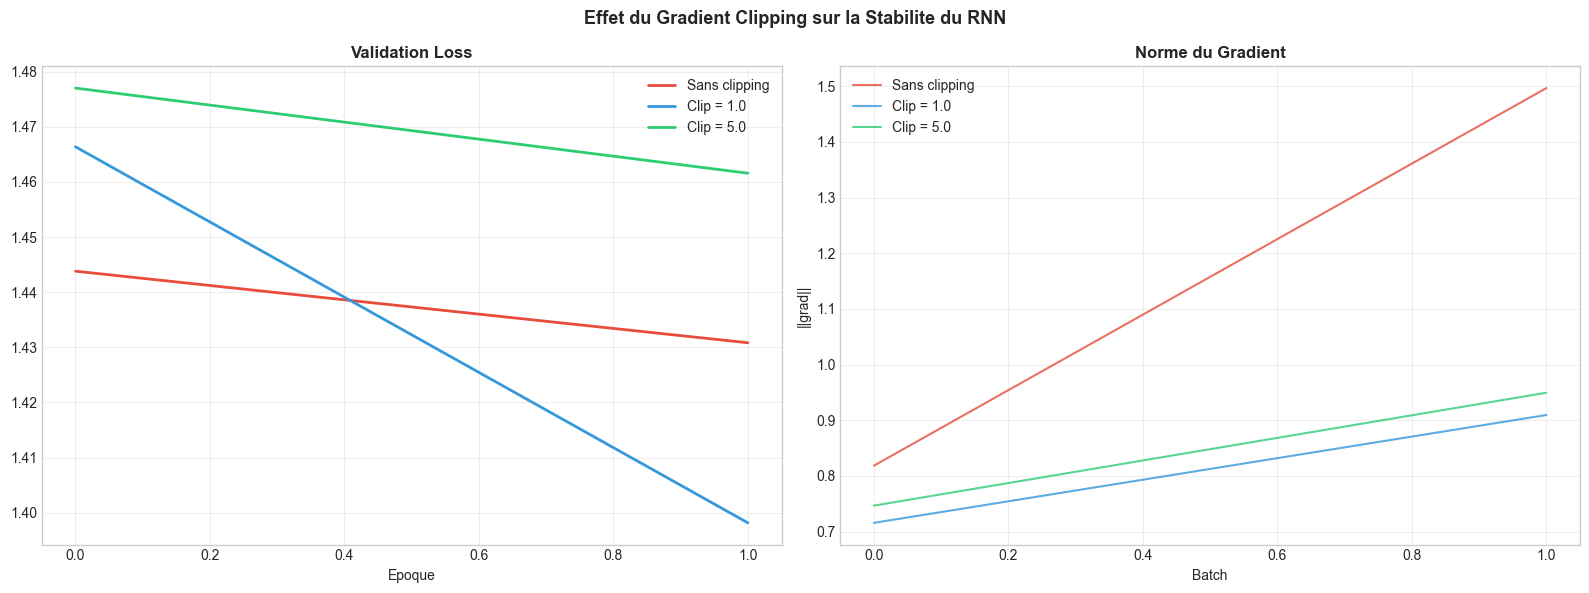

In [9]:
clip_configs = [
    ('Sans clipping',  None),
    ('Clip = 1.0',     1.0),
    ('Clip = 5.0',     5.0),
]

clip_results = {}

print('Etude du Gradient Clipping (RNN simple)')
print('='*55)

for label, clip_val in clip_configs:
    m = MedicalTextClassifier(
        VOCAB_SIZE, rnn_type='rnn', n_layers=2, hidden_dim=128
    )
    _, h = train_rnn(m, train_loader, val_loader,
                     n_epochs=2, clip=clip_val,
                     verbose=True, label=label)
    clip_results[label] = h

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Effet du Gradient Clipping sur la Stabilite du RNN',
             fontsize=13, fontweight='bold')

clip_colors = ['#e74c3c', '#3498db', '#2ecc71']

for (label, _), color in zip(clip_configs, clip_colors):
    h = clip_results[label]
    axes[0].plot(h['val_loss'], color=color, lw=2, label=label)
    axes[1].plot(h['grad_norms'], color=color, lw=1.5, alpha=0.8, label=label)

axes[0].set_title('Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoque'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Norme du Gradient', fontweight='bold')
axes[1].set_xlabel('Batch'); axes[1].set_ylabel('||grad||')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Mini Projet Seq2Seq — Résumé Automatique

In [10]:
class Encoder(nn.Module):
    """
    Encodeur LSTM du modele Seq2Seq.
    Lit la sequence d'entree et produit un vecteur de contexte.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers,
                            batch_first=True, dropout=dropout if n_layers>1 else 0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (hn, cn) = self.lstm(emb)
        return out, hn, cn


class Decoder(nn.Module):
    """
    Decodeur LSTM du modele Seq2Seq.
    Genere la sequence de sortie token par token.
    Utilise Teacher Forcing pendant l'entrainement.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers,
                            batch_first=True, dropout=dropout if n_layers>1 else 0)
        self.fc_out  = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, token, hn, cn):
        """Decode un seul token."""
        emb = self.dropout(self.embedding(token.unsqueeze(1)))
        out, (hn_new, cn_new) = self.lstm(emb, (hn, cn))
        logits = self.fc_out(out.squeeze(1))
        return logits, hn_new, cn_new


class Seq2Seq(nn.Module):
    """
    Modele Seq2Seq Encodeur-Decodeur pour le resume automatique.

    Pendant l'entrainement : Teacher Forcing
    Pendant l'inference    : Greedy Decoding ou Beam Search
    """

    SOS_IDX = 2
    EOS_IDX = 3

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, n_layers=2):
        super().__init__()
        self.encoder    = Encoder(vocab_size, embed_dim, hidden_dim, n_layers)
        self.decoder    = Decoder(vocab_size, embed_dim, hidden_dim, n_layers)
        self.vocab_size = vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Args:
            src : Source (B, src_len)
            tgt : Cible  (B, tgt_len) pour teacher forcing
            teacher_forcing_ratio : Probabilite d'utiliser le vrai token cible
        Returns:
            all_logits : (B, tgt_len, vocab_size)
        """
        B, tgt_len = tgt.shape
        _, hn, cn  = self.encoder(src)

        token      = tgt[:, 0]
        all_logits = []

        for t in range(1, tgt_len):
            logits, hn, cn = self.decoder.forward_step(token, hn, cn)
            all_logits.append(logits.unsqueeze(1))

            use_teacher = torch.rand(1).item() < teacher_forcing_ratio
            token = tgt[:, t] if use_teacher else logits.argmax(1)

        return torch.cat(all_logits, dim=1)

    def greedy_decode(self, src, max_len=20):
        """Decodage Greedy : choisit le token le plus probable a chaque etape."""
        self.eval()
        with torch.no_grad():
            _, hn, cn = self.encoder(src)
            token     = torch.tensor([self.SOS_IDX] * src.size(0)).to(src.device)
            generated = []
            for _ in range(max_len):
                logits, hn, cn = self.decoder.forward_step(token, hn, cn)
                token = logits.argmax(1)
                generated.append(token.unsqueeze(1))
                if (token == self.EOS_IDX).all(): break
        return torch.cat(generated, dim=1)

    def beam_search(self, src_single, max_len=20, beam_width=3):
        """
        Beam Search : conserve les beam_width meilleures hypotheses.

        Args:
            src_single : Source unique (1, src_len)
            beam_width : Nombre de faisceaux (2, 3 ou 5)
        Returns:
            Meilleure sequence generee
        """
        self.eval()
        with torch.no_grad():
            _, hn, cn = self.encoder(src_single)
            beams     = [(0.0, [self.SOS_IDX], hn, cn)]
            completed = []

            for step in range(max_len):
                new_beams = []

                for score, seq, h, c in beams:
                    if seq[-1] == self.EOS_IDX:
                        completed.append((score, seq))
                        continue

                    token = torch.tensor([seq[-1]]).to(src_single.device)
                    logits, h_new, c_new = self.decoder.forward_step(token, h, c)
                    log_probs = F.log_softmax(logits, dim=-1).squeeze(0)

                    topk_log_probs, topk_idx = log_probs.topk(beam_width)

                    for k in range(beam_width):
                        new_score = score + topk_log_probs[k].item()
                        new_seq   = seq + [topk_idx[k].item()]
                        new_beams.append((new_score, new_seq, h_new, c_new))

                beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]
                if not beams: break

            for score, seq, _, _ in beams:
                completed.append((score, seq))

            completed.sort(key=lambda x: x[0] / max(len(x[1]), 1), reverse=True)
            return completed[0][1] if completed else [self.SOS_IDX]


seq2seq = Seq2Seq(VOCAB_SIZE, embed_dim=64, hidden_dim=128)
params  = sum(p.numel() for p in seq2seq.parameters())
print(f'Seq2Seq — Parametres totaux : {params:,}')

src_test = torch.randint(1, VOCAB_SIZE, (2, MAX_LEN))
tgt_test = torch.randint(1, VOCAB_SIZE, (2, 15))
out_test = seq2seq(src_test, tgt_test)
print(f'Forward pass : src={src_test.shape}, tgt={tgt_test.shape} -> {out_test.shape}')

Seq2Seq — Parametres totaux : 5,760,646
Forward pass : src=torch.Size([2, 50]), tgt=torch.Size([2, 15]) -> torch.Size([2, 14, 20614])


In [11]:
class SummarizationDataset(Dataset):
    """
    Dataset pour la tache de resume automatique.
    Source : rapport medical complet
    Cible  : resume synthetique (premiers tokens + SOS/EOS)
    """
    def __init__(self, texts, vocab, src_len=50, tgt_len=12):
        self.src_len = src_len
        self.tgt_len = tgt_len
        sos = vocab.token2idx['<SOS>']
        eos = vocab.token2idx['<EOS>']
        pad = vocab.token2idx['<PAD>']
        unk = vocab.token2idx['<UNK>']

        self.sources = []
        self.targets = []

        for text in texts:
            src_ids  = vocab.encode(text, src_len)
            tokens   = vocab._tokenize(text)[:tgt_len-2]
            tgt_ids  = [sos]
            tgt_ids += [vocab.token2idx.get(t, unk) for t in tokens]
            tgt_ids += [eos]
            tgt_ids += [pad] * (tgt_len - len(tgt_ids))
            tgt_ids  = tgt_ids[:tgt_len]

            self.sources.append(torch.tensor(src_ids, dtype=torch.long))
            self.targets.append(torch.tensor(tgt_ids, dtype=torch.long))

    def __len__(self):         return len(self.sources)
    def __getitem__(self, i):  return self.sources[i], self.targets[i]


TGT_LEN      = 12
sum_train_ds = SummarizationDataset(train_texts, vocab, MAX_LEN, TGT_LEN)
sum_val_ds   = SummarizationDataset(val_texts,   vocab, MAX_LEN, TGT_LEN)

sum_train_loader = DataLoader(sum_train_ds, batch_size=32, shuffle=True)
sum_val_loader   = DataLoader(sum_val_ds,   batch_size=32)

print(f'Dataset Seq2Seq — Train: {len(sum_train_ds)} | Val: {len(sum_val_ds)}')

seq2seq       = seq2seq.to(device)
criterion_s2s = nn.CrossEntropyLoss(ignore_index=0)
optimizer_s2s = optim.Adam(seq2seq.parameters(), lr=1e-3)

print('\nEntrainement du modele Seq2Seq...')
s2s_losses = []

for epoch in range(1, 41):
    seq2seq.train()
    epoch_loss = 0
    for src, tgt in sum_train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer_s2s.zero_grad()
        out      = seq2seq(src, tgt, teacher_forcing_ratio=0.6)
        out_flat = out.reshape(-1, VOCAB_SIZE)
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss     = criterion_s2s(out_flat, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), 1.0)
        optimizer_s2s.step()
        epoch_loss += loss.item()

    s2s_losses.append(epoch_loss / len(sum_train_loader))
    if epoch % 10 == 0:
        ppl = math.exp(min(s2s_losses[-1], 20))
        print(f'  Epoque {epoch:>3} | Loss: {s2s_losses[-1]:.4f} | Perplexite: {ppl:.2f}')

print('\nEntrainement Seq2Seq termine')

Dataset Seq2Seq — Train: 1822 | Val: 390

Entrainement du modele Seq2Seq...


  Epoque  10 | Loss: 4.8718 | Perplexite: 130.55


  Epoque  20 | Loss: 4.0858 | Perplexite: 59.49


  Epoque  30 | Loss: 3.5636 | Perplexite: 35.29


  Epoque  40 | Loss: 3.0929 | Perplexite: 22.04

Entrainement Seq2Seq termine


In [12]:
def compute_bleu(reference: List[str], hypothesis: List[str]) -> float:
    """
    Calcul simplifie du BLEU-1 score.
    BLEU mesure le chevauchement de n-grammes entre reference et hypothese.
    """
    if not hypothesis: return 0.0
    ref_set   = set(reference)
    matches   = sum(1 for t in hypothesis if t in ref_set)
    precision = matches / len(hypothesis)
    bp        = min(1.0, math.exp(1 - len(reference) / max(len(hypothesis), 1)))
    return bp * precision


test_samples = [(sum_val_ds[i][0].unsqueeze(0).to(device),
                 val_texts[i]) for i in range(min(10, len(sum_val_ds)))]

print('\n' + '='*70)
print('  RESUME AUTOMATIQUE — Greedy Search vs Beam Search')
print('='*70)

bleu_greedy = []
bleu_beam   = {2: [], 3: [], 5: []}

for src_t, orig_text in test_samples[:5]:
    ref_tokens = vocab._tokenize(orig_text)[:10]

    greedy_ids    = seq2seq.greedy_decode(src_t, max_len=12)
    greedy_tokens = vocab.decode(greedy_ids[0].cpu().tolist()).split()
    bleu_g        = compute_bleu(ref_tokens, greedy_tokens)
    bleu_greedy.append(bleu_g)

    print(f'\n  Original   : {" ".join(ref_tokens[:10])}')
    print(f'  Greedy     : {" ".join(greedy_tokens[:10])} (BLEU={bleu_g:.3f})')

    for bw in [2, 3, 5]:
        beam_ids    = seq2seq.beam_search(src_t, max_len=12, beam_width=bw)
        beam_tokens = vocab.decode(beam_ids).split()
        bleu_b      = compute_bleu(ref_tokens, beam_tokens)
        bleu_beam[bw].append(bleu_b)
        print(f'  Beam(w={bw})  : {" ".join(beam_tokens[:10])} (BLEU={bleu_b:.3f})')

print('\n' + '='*70)
print('  BLEU SCORES MOYENS')
print('='*70)
print(f'  Greedy Search   : {np.mean(bleu_greedy):.4f}')
for bw in [2, 3, 5]:
    print(f'  Beam Search w={bw} : {np.mean(bleu_beam[bw]):.4f}')


  RESUME AUTOMATIQUE — Greedy Search vs Beam Search

  Original   : procedure laparoscopy with ablation of endometriosis diagnosis endometriosis anesthesia general
  Greedy     : procedure performed of of the left and anesthesia anesthesia performed (BLEU=0.455)
  Beam(w=2)  : <SOS> procedure performed of of the left and anesthesia anesthesia (BLEU=0.417)
  Beam(w=3)  : <SOS> procedure performed of of the left and anesthesia anesthesia (BLEU=0.417)
  Beam(w=5)  : <SOS> title of operation of of of the left and (BLEU=0.333)

  Original   : preoperative diagnoses c5-c6 disc herniation with right arm radiculopathy postoperative
  Greedy     : preoperative diagnoses 1 left abductovalgus 2 2 2 2 3 (BLEU=0.182)
  Beam(w=2)  : <SOS> preoperative diagnoses 1 left pregnancy 2 2 2 2 (BLEU=0.167)
  Beam(w=3)  : <SOS> preoperative diagnoses 1 left pregnancy 2 2 2 2 (BLEU=0.167)


  Beam(w=5)  : <SOS> preoperative diagnoses 1 left spondylosis 2 left 2 2 (BLEU=0.167)

  Original   : preoperative diagnosis left carpal tunnel syndrome postoperative diagnosis left carpal
  Greedy     : preoperative diagnosis left right tunnel syndrome postoperative diagnosis left carpal (BLEU=0.818)
  Beam(w=2)  : <SOS> preoperative diagnosis left carpal tunnel syndrome postoperative diagnosis left (BLEU=0.833)
  Beam(w=3)  : <SOS> preoperative diagnosis left carpal tunnel syndrome postoperative diagnosis left (BLEU=0.833)
  Beam(w=5)  : <SOS> preoperative diagnosis left carpal tunnel syndrome postoperative diagnosis left (BLEU=0.833)

  Original   : subjective this 45-year-old gravida 3 para 2 sab 1 white
  Greedy     : cc mri hx this y o rhf rhf to the (BLEU=0.091)
  Beam(w=2)  : <SOS> reason for visit this y o to to the (BLEU=0.083)
  Beam(w=3)  : <SOS> reason for visit this y o to to the (BLEU=0.083)


  Beam(w=5)  : <SOS> cc headache hx this y y o rhf to (BLEU=0.083)

  Original   : reason for examination cardiac arrhythmia interpretation no significant pericardial effusion
  Greedy     : exam mri left left pain and contrast history of present (BLEU=0.000)
  Beam(w=2)  : <SOS> reason for consultation left pain and contrast history of (BLEU=0.167)
  Beam(w=3)  : <SOS> reason for consultation management of the left knee and (BLEU=0.167)
  Beam(w=5)  : <SOS> reason for consultation management of of the left knee (BLEU=0.167)

  BLEU SCORES MOYENS
  Greedy Search   : 0.3091
  Beam Search w=2 : 0.3333
  Beam Search w=3 : 0.3333
  Beam Search w=5 : 0.3167


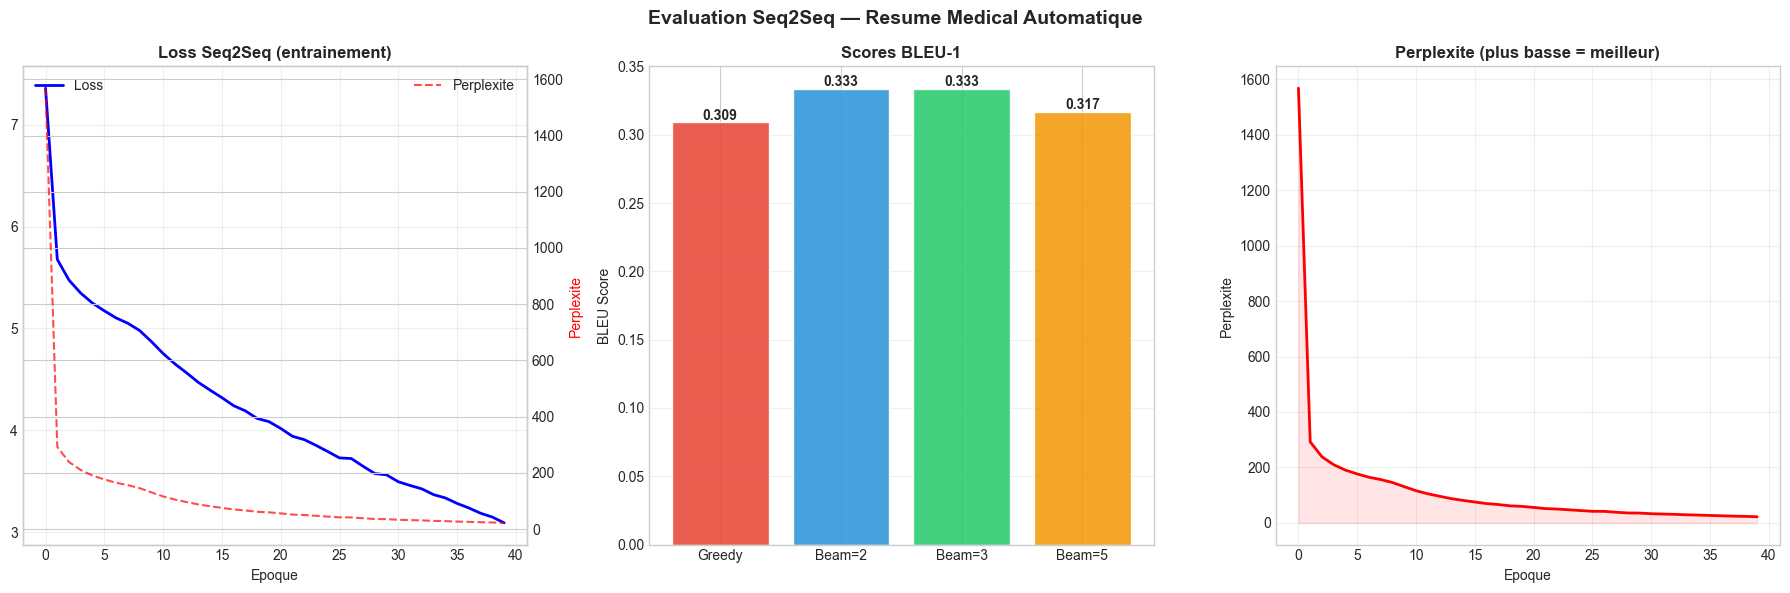

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluation Seq2Seq — Resume Medical Automatique',
             fontsize=14, fontweight='bold')

perplexities = [math.exp(min(l, 20)) for l in s2s_losses]
axes[0].plot(s2s_losses, 'b-', lw=2, label='Loss')
axes[0].set_title('Loss Seq2Seq (entrainement)', fontweight='bold')
axes[0].set_xlabel('Epoque'); axes[0].grid(alpha=0.3)
ax2 = axes[0].twinx()
ax2.plot(perplexities, 'r--', lw=1.5, label='Perplexite', alpha=0.7)
ax2.set_ylabel('Perplexite', color='red')
axes[0].legend(loc='upper left'); ax2.legend(loc='upper right')

beam_labels = ['Greedy', 'Beam=2', 'Beam=3', 'Beam=5']
beam_bleus  = [np.mean(bleu_greedy)] + [np.mean(bleu_beam[w]) for w in [2,3,5]]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = axes[1].bar(beam_labels, beam_bleus, color=colors, edgecolor='white', alpha=0.9)
for b, val in zip(bars, beam_bleus):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Scores BLEU-1', fontweight='bold')
axes[1].set_ylabel('BLEU Score'); axes[1].grid(axis='y', alpha=0.3)

axes[2].plot(perplexities, 'r-', lw=2)
axes[2].fill_between(range(len(perplexities)), perplexities, alpha=0.1, color='red')
axes[2].set_title('Perplexite (plus basse = meilleur)', fontweight='bold')
axes[2].set_xlabel('Epoque'); axes[2].set_ylabel('Perplexite'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
summary = pd.DataFrame([
    {
        'Modele': name.upper(),
        'Accuracy (%)': round(m['accuracy']*100, 2),
        'Parametres': f"{m['params']:,}",
        'Temps (s)': round(m['time'], 1),
        'Gradient Vanishing': 'Severe' if name=='rnn' else 'Controle',
        'Complexite': 'Faible' if name=='rnn' else ('Haute' if name=='lstm' else 'Moyenne'),
    }
    for name, m in rnn_metrics.items()
])

print('Tableau Comparatif Final — RNN / LSTM / GRU')
summary.style.highlight_max(subset=['Accuracy (%)'], color='lightgreen')

Tableau Comparatif Final — RNN / LSTM / GRU


,Modele,Accuracy (%),Parametres,Temps (s),Gradient Vanishing,Complexite
0,RNN,56.010000,"1,385,733",2.900000,Severe,Faible
1,LSTM,56.520000,"1,559,301",4.100000,Controle,Haute
2,GRU,59.080000,"1,501,445",10.600000,Controle,Moyenne


---
## 7. Question de Synthèse

### Pourquoi les architectures LSTM et GRU surpassent-elles généralement les RNN classiques ?

---

### Le Problème du Gradient Vanissant dans les RNN

Dans un RNN classique, lors de la rétropropagation à travers le temps (BPTT) :

$$\frac{\partial h_t}{\partial h_0} = \prod_{k=1}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=1}^{t} W_{hh}^T \text{diag}(\tanh'(z_k))$$

Si la valeur propre maximale de $W_{hh}$ est inférieure à 1, le gradient tend vers 0 exponentiellement (vanishing). Si elle est supérieure à 1, le gradient explose.

### Comment LSTM et GRU résolvent ce problème

| Mécanisme | RNN | LSTM | GRU |
|-----------|-----|------|-----|
| **Gating** | Aucun | 3 portes (f, i, o) | 2 portes (z, r) |
| **Mémoire long terme** | Limitée | Cell state | Intégrée |
| **Flux du gradient** | Décroissance exponentielle | Protégé par la porte d'oubli | Protégé par la porte de mise à jour |
| **Complexité** | Simple | Haute | Moyenne |
| **Textes médicaux** | Perd le contexte distant | Capture les dépendances longues | Similaire au LSTM |

### Conclusion

Le LSTM et le GRU résolvent le problème du gradient vanissant grâce à des mécanismes de portes qui contrôlent sélectivement l'information conservée, oubliée ou exposée. Dans le contexte médical, les rapports contiennent souvent des dépendances longues : un symptôme mentionné en début de rapport peut définir le diagnostic final. Ces architectures sont donc indispensables pour une classification fiable. Le GRU offre un bon compromis entre performance et efficacité computationnelle, tandis que le LSTM reste la référence pour les séquences très longues.